## Prophet Model

#### Section 1
1. [Step 1:Importing packages, Daily Pediatric ED dataset and data pre-processing](#sec1)
2. [Step 2:Creating and fitting two prophet models](#sec2)
3. [Step 3:Rolling origin cross validation for MAE and MAPE](#sec3)
4. [Step 4:Evaluating prediction interval coverage(Winkler score, ACD,Empirical Coverage) of a 28day forecast](#sec4)
   1. [Step 4a: A Simple train-test split, model fit and prediction](#sec4)
   2. [Step 4b: Winkler score, ACD, Empirical coverage](#sec5)
#### Section 2
**[A 28 days forecast on daily pediatric ED attendances for NHS Trust](#sec6)**

----------------------------------------------------------------------------------------------------

#### Step 1: Importing packages, Daily Pediatric ED dataset and data pre-processing <a id='sec1'></a> 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet.diagnostics import cross_validation, performance_metrics
from prophet import Prophet
from prophet.plot import plot_forecast_component
from forecast_tools.metrics import (
 absolute_coverage_difference,
 winkler_score, coverage
)
from prophet.plot import plot_plotly

In [3]:
# importing pediatric dataset on daily emergency attendances
ed_daily = pd.read_csv(
    "paediatrics_train.csv", parse_dates=True, index_col="date", dayfirst=False
)
ed_daily.index.freq = "D"

In [4]:
import forecast_tools
print(forecast_tools.__version__)

0.4.1


In [5]:
def prophet_training_data(y_train):
    """
    Converts a standard pandas datetimeindexed dataframe
    for time series into one suitable for Prophet
    Parameters:
    ---------
    y_train: pd.DataFrame
        univariate time series data

    Returns:
    --------
        pd.DataFrame in Prophet format
        columns = ['ds', 'y']
    """
    prophet_train = pd.DataFrame(y_train.index)
    prophet_train["y"] = y_train.to_numpy()
    prophet_train.columns = ["ds", "y"]

    return prophet_train


# Converting dataset into prophet format
ed_attends = prophet_training_data(ed_daily)

#### Step 2: Creating and fitting two prophet models <a id='sec2'></a> 

In [6]:
# Creating the first prophet model
prophet1 = Prophet(interval_width=0.95)
prophet1.fit(ed_attends)

# Creating the Second prophet model with added holidays
prophet2 = Prophet(interval_width=0.95)
prophet2.add_country_holidays(country_name="UK")
prophet2.fit(ed_attends)

21:59:41 - cmdstanpy - INFO - Chain [1] start processing
21:59:41 - cmdstanpy - INFO - Chain [1] done processing
21:59:41 - cmdstanpy - INFO - Chain [1] start processing
21:59:42 - cmdstanpy - INFO - Chain [1] done processing


#### Step 3: Rolling origin cross validation for MAE and MAPE <a id='sec3'></a> 

In [7]:
# Using rolling origin cross validation method to evaluate both models


def mode(mod):
    """
    A function that generates point forecast accuracy performance metrics
    for prophet models through cross validation over 28days horizon
    it uses a minimum train size of 916 days and a 28 day forward step

    Parameter
    ---------
    mod: A fitted prophet model

    Return
    ------
    pandas.DataFrame of cv performance metrics

    """
    df_cv = cross_validation(
        model=mod, initial="916 days", period="28 days", horizon="28 days"
    )
    df_p = performance_metrics(df_cv, rolling_window=0)
    return df_p


pf1 = mode(prophet1)
pf2 = mode(prophet2)

  0%|          | 0/4 [00:00<?, ?it/s]

21:59:42 - cmdstanpy - INFO - Chain [1] start processing
21:59:42 - cmdstanpy - INFO - Chain [1] done processing
21:59:42 - cmdstanpy - INFO - Chain [1] start processing
21:59:42 - cmdstanpy - INFO - Chain [1] done processing
21:59:42 - cmdstanpy - INFO - Chain [1] start processing
21:59:42 - cmdstanpy - INFO - Chain [1] done processing
21:59:42 - cmdstanpy - INFO - Chain [1] start processing
21:59:42 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/4 [00:00<?, ?it/s]

21:59:43 - cmdstanpy - INFO - Chain [1] start processing
21:59:43 - cmdstanpy - INFO - Chain [1] done processing
21:59:43 - cmdstanpy - INFO - Chain [1] start processing
21:59:43 - cmdstanpy - INFO - Chain [1] done processing
21:59:43 - cmdstanpy - INFO - Chain [1] start processing
21:59:43 - cmdstanpy - INFO - Chain [1] done processing
21:59:43 - cmdstanpy - INFO - Chain [1] start processing
21:59:43 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
prophet1 = round(pf1.iloc[[6, 13, 20, 27], [0, 3, 4]],2)
prophet1

,horizon,mae,mape
6,7 days,8.42,0.17
13,14 days,7.34,0.12
20,21 days,6.27,0.11
27,28 days,9.94,0.26


In [9]:
prophet2 = round(pf2.iloc[[6, 13, 20, 27], [0, 3, 4]], 2)
prophet2

,horizon,mae,mape
6,7 days,7.54,0.15
13,14 days,7.36,0.12
20,21 days,6.14,0.11
27,28 days,6.36,0.15


#### Step 4: Evaluating prediction interval coverage(Winkler score, ACD,Empirical Coverage) of a 28day forecast <a id='sec4'></a>

##### Step 4a: A Simple train-test split, model fit and prediction <a id='sec5'></a>

In [10]:
# Splitting dataset into training and testing set
train = ed_attends.iloc[:-28]
test = ed_attends.iloc[-28:]

In [11]:
# Fitting Prophet model 2 into the training data
prophet_2 = Prophet(interval_width=0.95)
prophet_2.add_country_holidays(country_name="UK")
prophet_2.fit(train)

21:59:44 - cmdstanpy - INFO - Chain [1] start processing
21:59:44 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
# Making a 28days forecast
future = prophet_2.make_future_dataframe(periods=28)
proph_pred = prophet_2.predict(future)

# Extracting the upper and lower predicted values for interval estimation
intervals = proph_pred.iloc[-28:, [2, 3]]

# Converting predicted intervals to numpy for evaluate PIC
pred_interval = intervals[["yhat_lower", "yhat_upper"]].to_numpy()

##### Step 4b: Winkler score, ACD, Empirical coverage <a id='sec5'></a>

In [13]:
# Assessing prophet's 95% interval coverage using winkler score,
# absolute coverage difference and empirical coverage

winkler_proph = winkler_score(
    y_true=test.y, intervals=pred_interval, alpha=0.05
)

acd_proph = absolute_coverage_difference(
    y_true=test.y, intervals=pred_interval, alpha=0.05
)

cover_proph = coverage(y_true=test.y, pred_intervals=pred_interval)

print("Winkler_score:\n", round(winkler_proph, 2))
print("Absolute_coverage_diff:\n", round(acd_proph, 2))
print("Empirical Coverage:\n", round(cover_proph, 2))

Winkler_score:
 30.02
Absolute_coverage_diff:
 0.01
Empirical Coverage:
 0.96


In [14]:
Prophet_PIC= pd.DataFrame({
            'empirical Coverage()':[cover_proph],
            'ACD':[acd_proph],
            'winkler_score': [winkler_proph]})
Prophet_PIC = Prophet_PIC.T 
Prophet_PIC=Prophet_PIC.rename(columns={0:'estimated values'})
Prophet_PIC

,estimated values
empirical Coverage(),0.964286
ACD,0.014286
winkler_score,30.022313


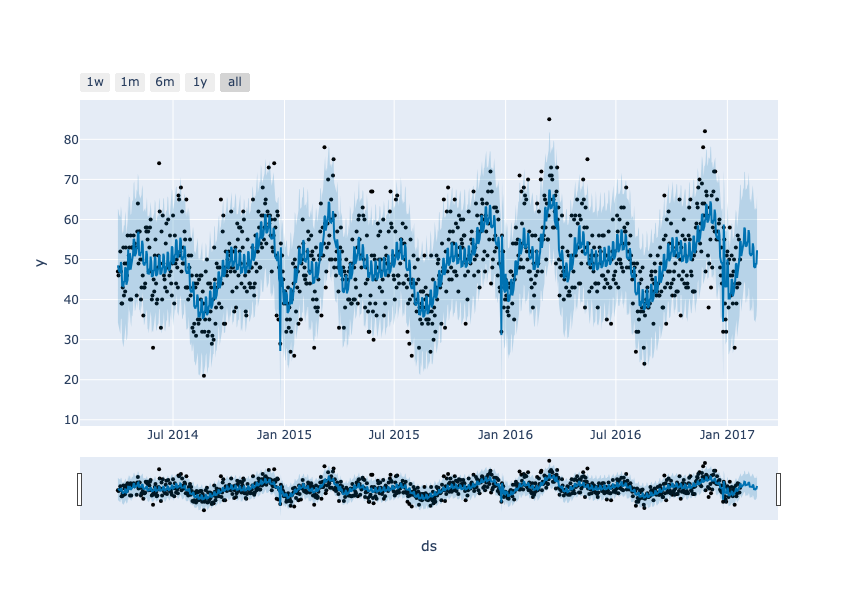

In [15]:
plot_plotly(prophet_2, proph_pred)

### Section2: A 28 days forecast on daily pediatric ED attendances <a id='sec6'></a>

In [16]:
# Using Prophet model_2 to make an actual 28day forecast

pf_2 = Prophet(interval_width=0.95)
pf_2.add_country_holidays(country_name="UK")
pf_2.fit(ed_attends)

future2 = pf_2.make_future_dataframe(periods=28)
pred_val = pf_2.predict(future2)

21:59:46 - cmdstanpy - INFO - Chain [1] start processing
21:59:46 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
# Extracting the 28days prediction
pred_28 = pred_val.iloc[-28:, [0, -1]]

print(pred_28.yhat.min())
print(pred_28.yhat.max())
print(pred_28.yhat.mean())

45.86953720733091
66.64701381366983
57.20821930842829


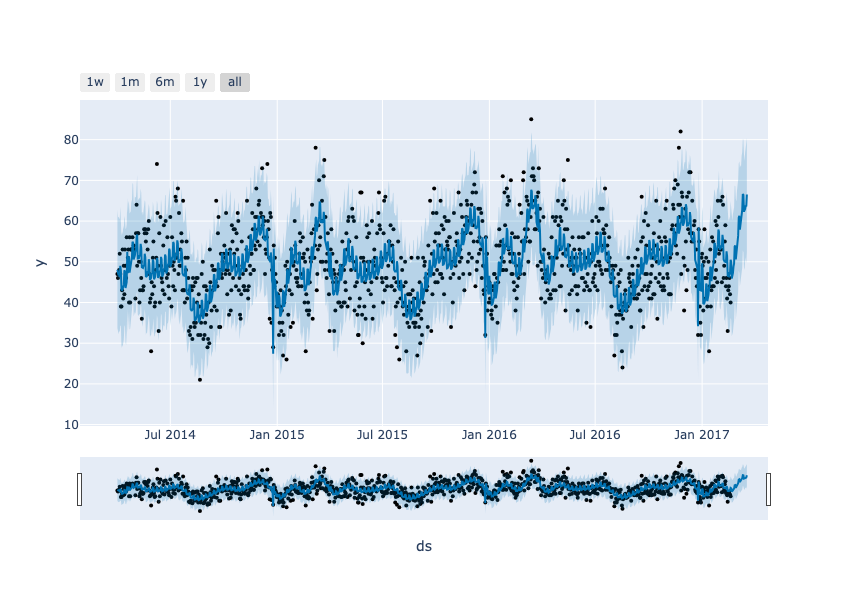

In [18]:
# data visualisation
plot_plotly(pf_2, pred_val)

In [19]:
# Predicted pediatrics ED attendances from 20th,February to 19th,March
pred_28

,ds,yhat
1056,2017-02-20,50.016454
1057,2017-02-21,45.869537
1058,2017-02-22,46.386333
1059,2017-02-23,47.228875
1060,2017-02-24,48.823286
1061,2017-02-25,49.597062
1062,2017-02-26,53.747486
1063,2017-02-27,54.009238
1064,2017-02-28,50.576396
1065,2017-03-01,51.746481


/home/ubuntu/.miniconda3/envs/hds_forecast/lib/python3.11/site-packages/prophet/plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/home/ubuntu/.miniconda3/envs/hds_forecast/lib/python3.11/site-packages/prophet/plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



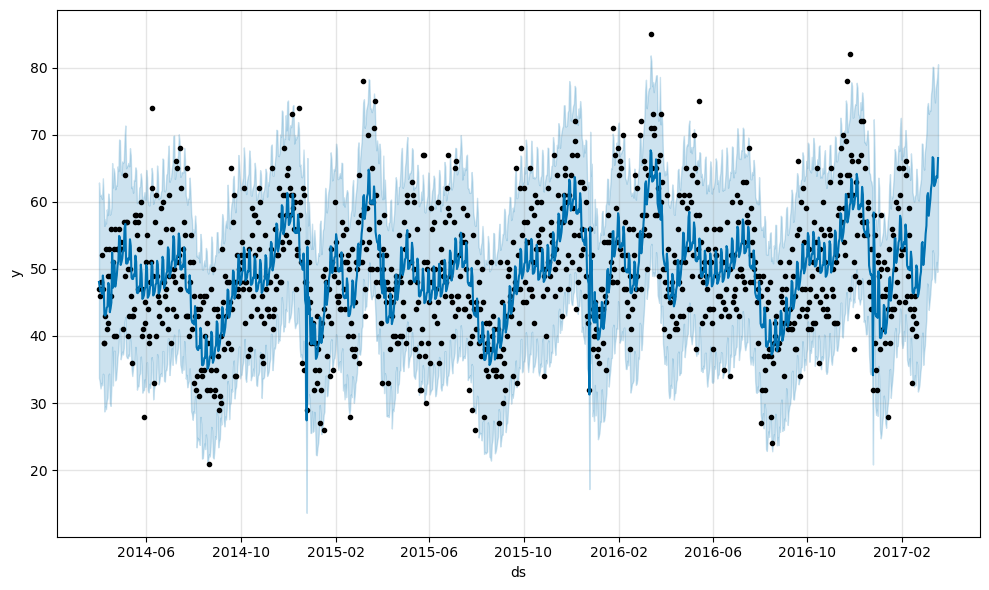

In [20]:
# data visualisation
pf_2.plot(pred_val)
plt.savefig("pf_forecast.png", dpi=300)

/home/ubuntu/.miniconda3/envs/hds_forecast/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/home/ubuntu/.miniconda3/envs/hds_forecast/lib/python3.11/site-packages/prophet/plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/home/ubuntu/.miniconda3/envs/hds_forecast/lib/python3.11/site-packages/prophet/plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the 

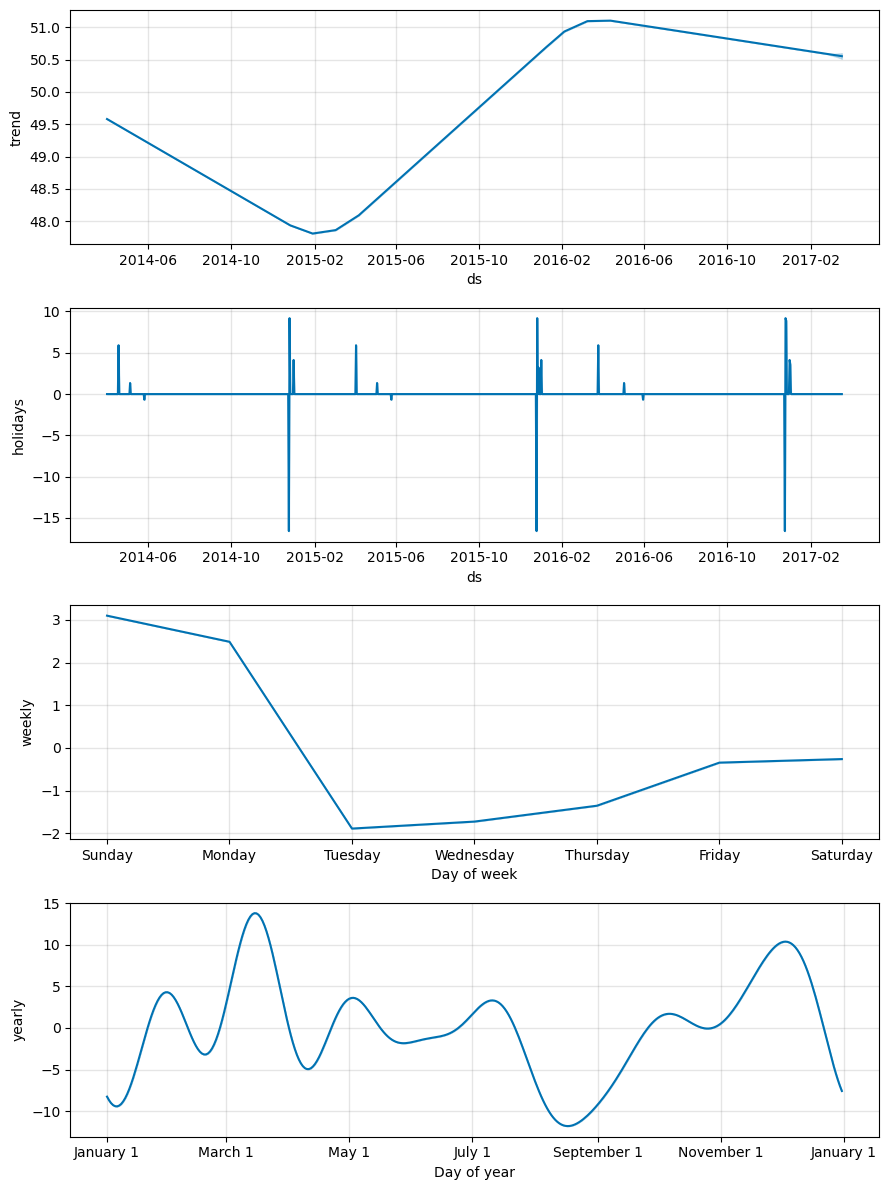

In [21]:
# Data Visualization of trends, holiday effects,
# weekly and yearly seasonality
pf_2.plot_components(pred_val)
plt.savefig("plot_components")

/home/ubuntu/.miniconda3/envs/hds_forecast/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



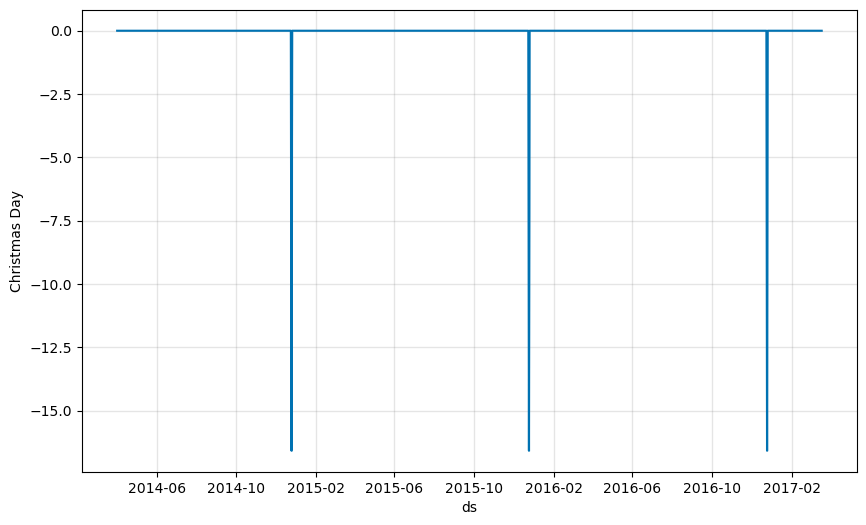

In [22]:
# data visualisation of christmas day effect
plot_forecast_component(pf_2, pred_val, "Christmas Day")

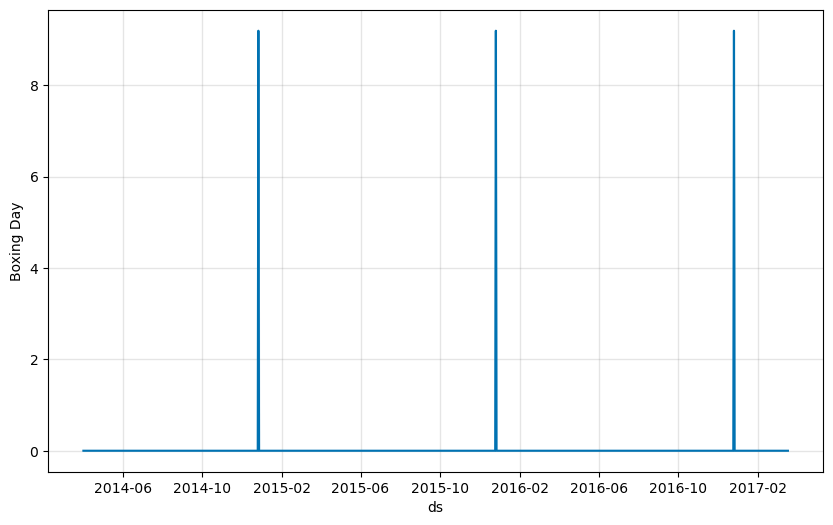

In [23]:
# data visualisation of boxing day day effect
plot_forecast_component(pf_2, pred_val, "Boxing Day")

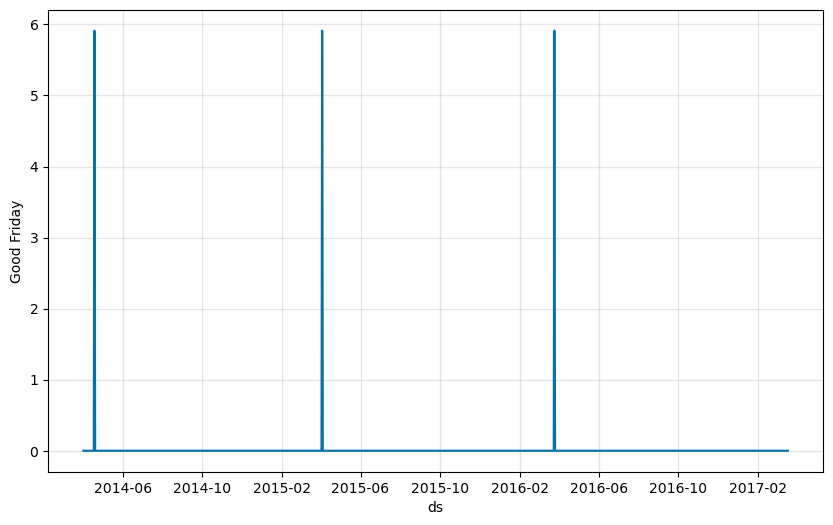

In [24]:
# data visualisation of good friday day effect
plot_forecast_component(pf_2, pred_val, "Good Friday")